In [3]:
%%capture
! pip install laspy 
! pip install rasterio

# Loading and visualizing the dataset

In [1]:
import geopandas as gpd
import laspy
from laspy import read
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from matplotlib.colors import ListedColormap
import warnings

In [2]:
pd.set_option('display.width', 1000) # Set max display width to 1000 characters
warnings.filterwarnings("ignore") # Suppress all warnings

# Field survey

In [3]:
field_survey = gpd.read_file("../data/field_survey.geojson")


print("Shape of the DataFrame:", field_survey.shape)
print("\nHead of the DataFrame:")
print(field_survey.head())

print("\nColumn Data Types:")
print(field_survey.dtypes)

print("\nDescriptive Statistics:")
print(field_survey.describe())

missing_data = pd.DataFrame({
    "Column": field_survey.columns,
    "Count": field_survey.isnull().sum(),
    "Percentage": round((field_survey.isnull().sum() / len(field_survey)) * 100, 2)
})

missing_data.reset_index(drop=True, inplace=True)
print("\nMissing Values Summary:")
print(missing_data.to_string(index=False))


Shape of the DataFrame: (3602, 11)

Head of the DataFrame:
   plot  tree_no species    d1    d2    dbh   age  height  angle comment                        geometry
0   1.0      1.0   Birch  47.2  46.2  46.70   NaN    26.5    0.0    None   POINT (547075.84 6450425.243)
1   1.0      2.0   Aspen  27.9  29.1  28.50   NaN     NaN    0.0    None  POINT (547074.299 6450419.542)
2   1.0      3.0     Fir  12.1  13.0  12.55   NaN     NaN    0.0    None  POINT (547077.454 6450419.994)
3   1.0      4.0   Aspen  23.3  23.7  23.50  69.0    27.4    0.0    None   POINT (547078.211 6450419.02)
4   1.0      5.0   Aspen  23.2  31.3  27.25   NaN     NaN    0.0    None  POINT (547074.669 6450415.573)

Column Data Types:
plot         float64
tree_no      float64
species       object
d1           float64
d2           float64
dbh          float64
age          float64
height       float64
angle        float64
comment       object
geometry    geometry
dtype: object

Descriptive Statistics:
              plot   

In [4]:
species_counts = field_survey.value_counts("species").reset_index()
species_counts["percentage"] = round((species_counts["count"] / species_counts["count"].sum()) * 100, 2)
species_counts

,species,count,percentage
0,Spruce,1144,31.76
1,Birch,676,18.77
2,Fir,663,18.41
3,Aspen,598,16.60
4,Tilia,370,10.27
5,Alder,121,3.36
6,Willow,28,0.78
7,Elm,1,0.03
8,Pine,1,0.03


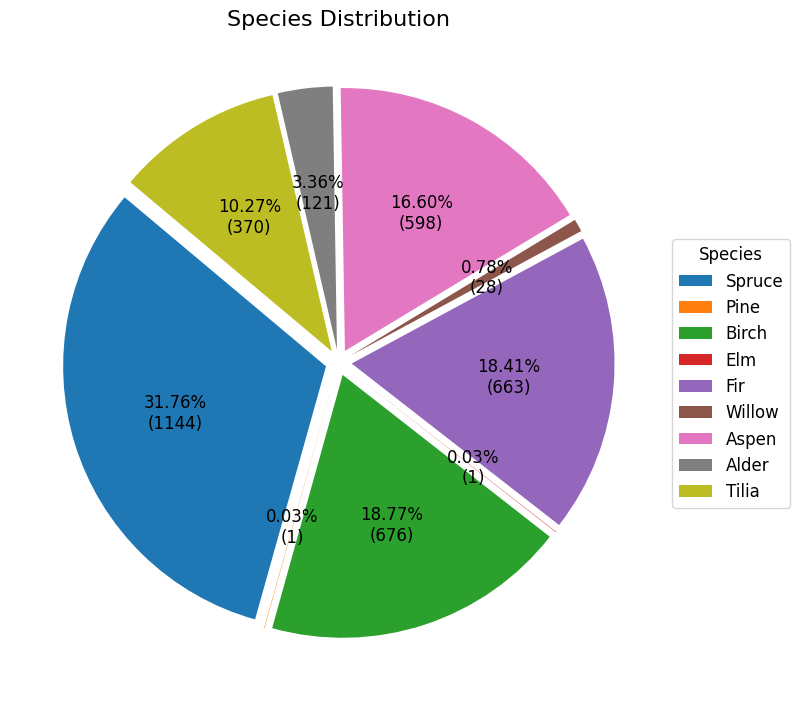

In [5]:
desired_order = ["Spruce", "Pine", "Birch", "Elm", "Fir", "Willow", "Aspen", "Alder", "Tilia"]
species_counts = species_counts.set_index("species").loc[desired_order].reset_index()

explode = [0.05] * len(species_counts["count"]) 


plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    species_counts["count"],  
    explode=explode, 
    startangle=140,
    autopct=lambda p: f'{p:.2f}%\n({int(p * species_counts["count"].sum() / 100)+1})',  
    textprops={'fontsize': 12}
)

plt.title("Species Distribution", fontsize=16)
plt.legend(wedges, species_counts["species"],
           title="Species", loc="upper right", 
           bbox_to_anchor=(1.2, 0.7), fontsize=12, 
           title_fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
conifiers = {"Spruce", "Fir", "Pine"}
species_counts["type"] = species_counts["species"].map(lambda x: "Coniferous" if x in conifiers else "Deciduous")
species_counts = species_counts.sort_values(by="count", ascending=False)

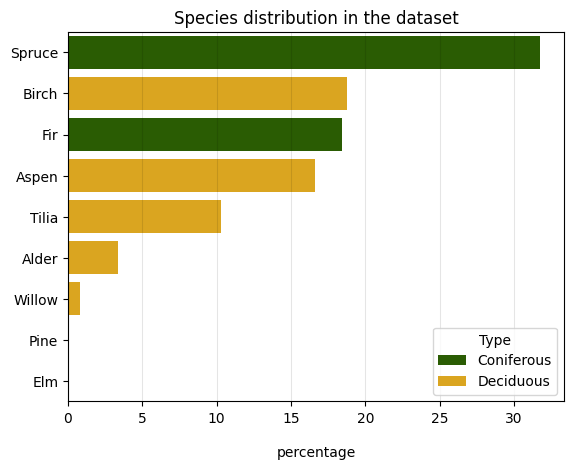

In [7]:
ax = sns.barplot(
    data=species_counts,
    x="percentage",
    y="species",
    hue="type",
    dodge=False,
    hue_order=["Coniferous", "Deciduous"],
    palette=["#2A5C03", "#DAA520"],
    saturation=1,
)
ax.set_title("Species distribution in the dataset")
ax.grid(axis="x", color="black", alpha=0.1)
plt.xlabel("percentage", labelpad=15)
plt.ylabel("")    
plt.legend(loc="lower right", title="Type")
plt.show()


In [8]:
# Check if dbh is the mean of d1 and d2 for all rows 
validation_result = (round((field_survey["d1"] + field_survey["d2"]) / 2, 2 )== field_survey["dbh"]).all()
if validation_result:
    print("dbh is the mean of d1 and d2.")
else:
    print("dbh is not the mean of d1 and d2.")


dbh is the mean of d1 and d2.


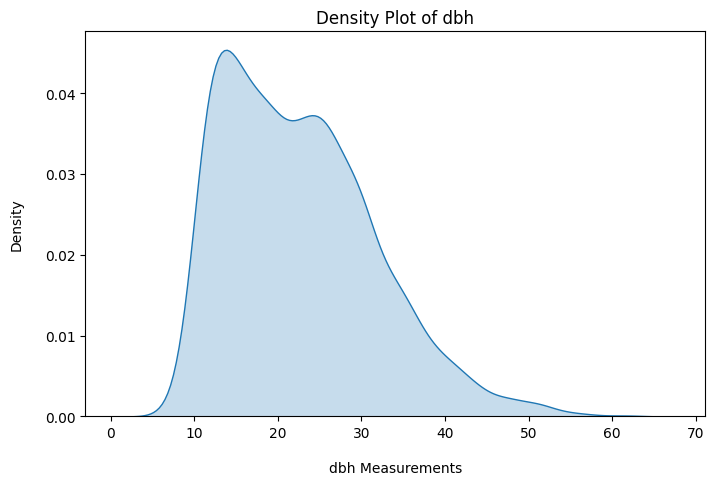

In [9]:
plt.figure(figsize=(8, 5))
sns.kdeplot(field_survey["dbh"], fill=True)

plt.title("Density Plot of dbh")
plt.xlabel("dbh Measurements", labelpad=15)
plt.ylabel("Density", labelpad=15)
plt.show()

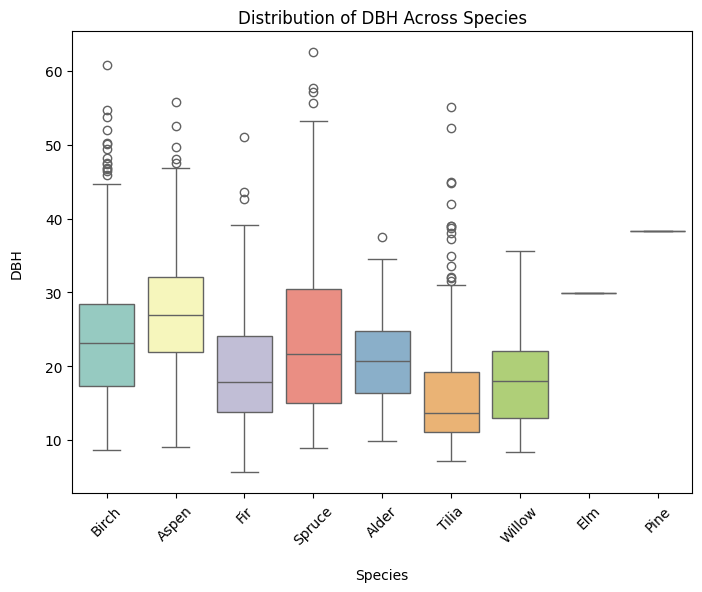

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=field_survey, x='species', y='dbh', palette='Set3')
plt.title('Distribution of DBH Across Species')
plt.xlabel('Species', labelpad=15)
plt.ylabel('DBH', labelpad= 15)
plt.xticks(rotation=45)
plt.show()

In [11]:
field_survey["type"] = field_survey["species"].map(lambda x: "Coniferous" if x in conifiers else "Deciduous")

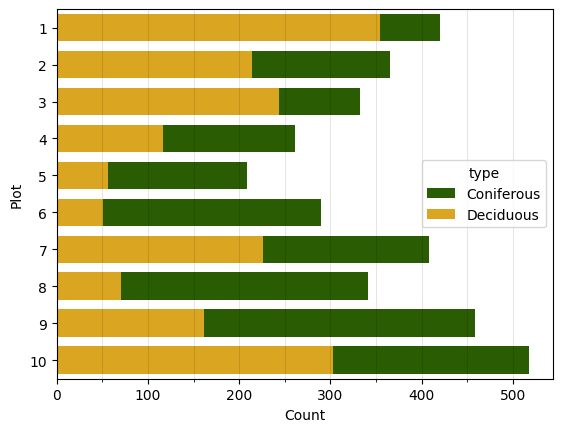

In [12]:
ax = sns.histplot(
    data=field_survey,
    y="plot",
    discrete=True,
    hue="type",
    hue_order=["Coniferous", "Deciduous"],
    palette=["#2A5C03", "#DAA520"],
    multiple="stack",
    shrink=0.75,
    alpha=1,
    lw=0,
)
ax.set_ylim(10.5, 0.5)
ax.set_ylabel("Plot")
ax.yaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_minor_locator(plt.MultipleLocator(50))
ax.grid(axis="x", color="black", alpha=0.1)
ax.grid(axis="x", which="minor", color="black", alpha=0.1)

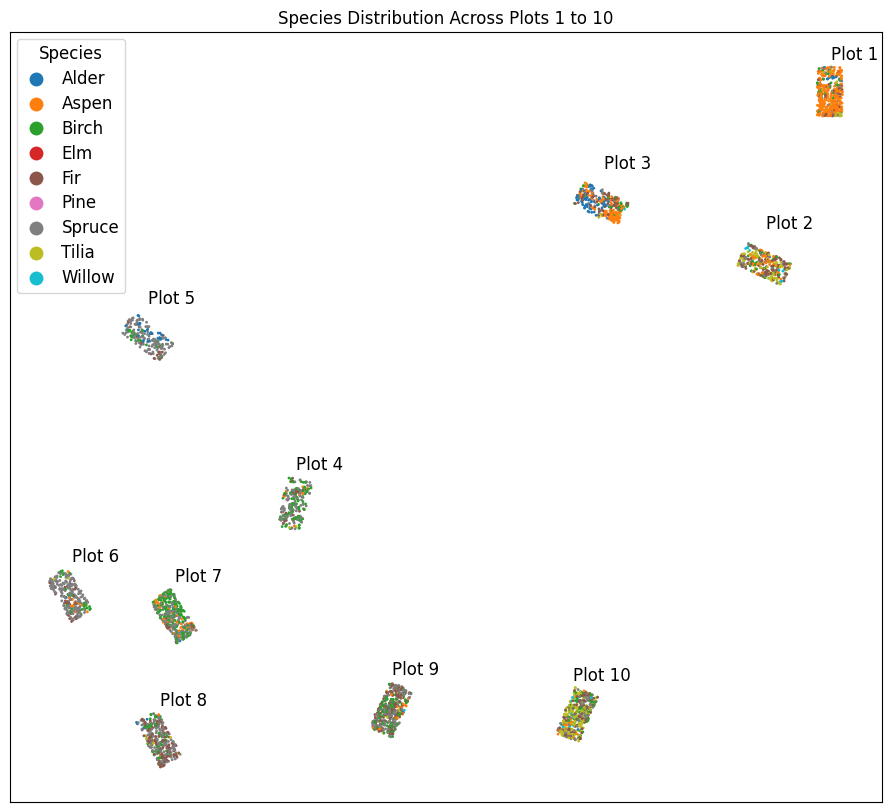

In [13]:
ax = field_survey.plot(
    column="species",
    legend=True,
    s=1,
    figsize=(15, 10),
    aspect="equal",
)

for plot_id, group in field_survey.groupby("plot"):
    avg_lon = group.geometry.x.mean()
    avg_lat = group.geometry.y.mean()
    ax.text(
        avg_lon + 50,
        avg_lat + 80,
        f"Plot {int(plot_id)}",
        fontsize=12,  
        color="black",
        ha="center",
        va="center",
    )

legend = ax.get_legend()
if legend:
    legend.set_title("Species", prop={"size": 12})  
    for text in legend.get_texts():
        text.set_fontsize(12)  

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Species Distribution Across Plots 1 to 10")
plt.show()


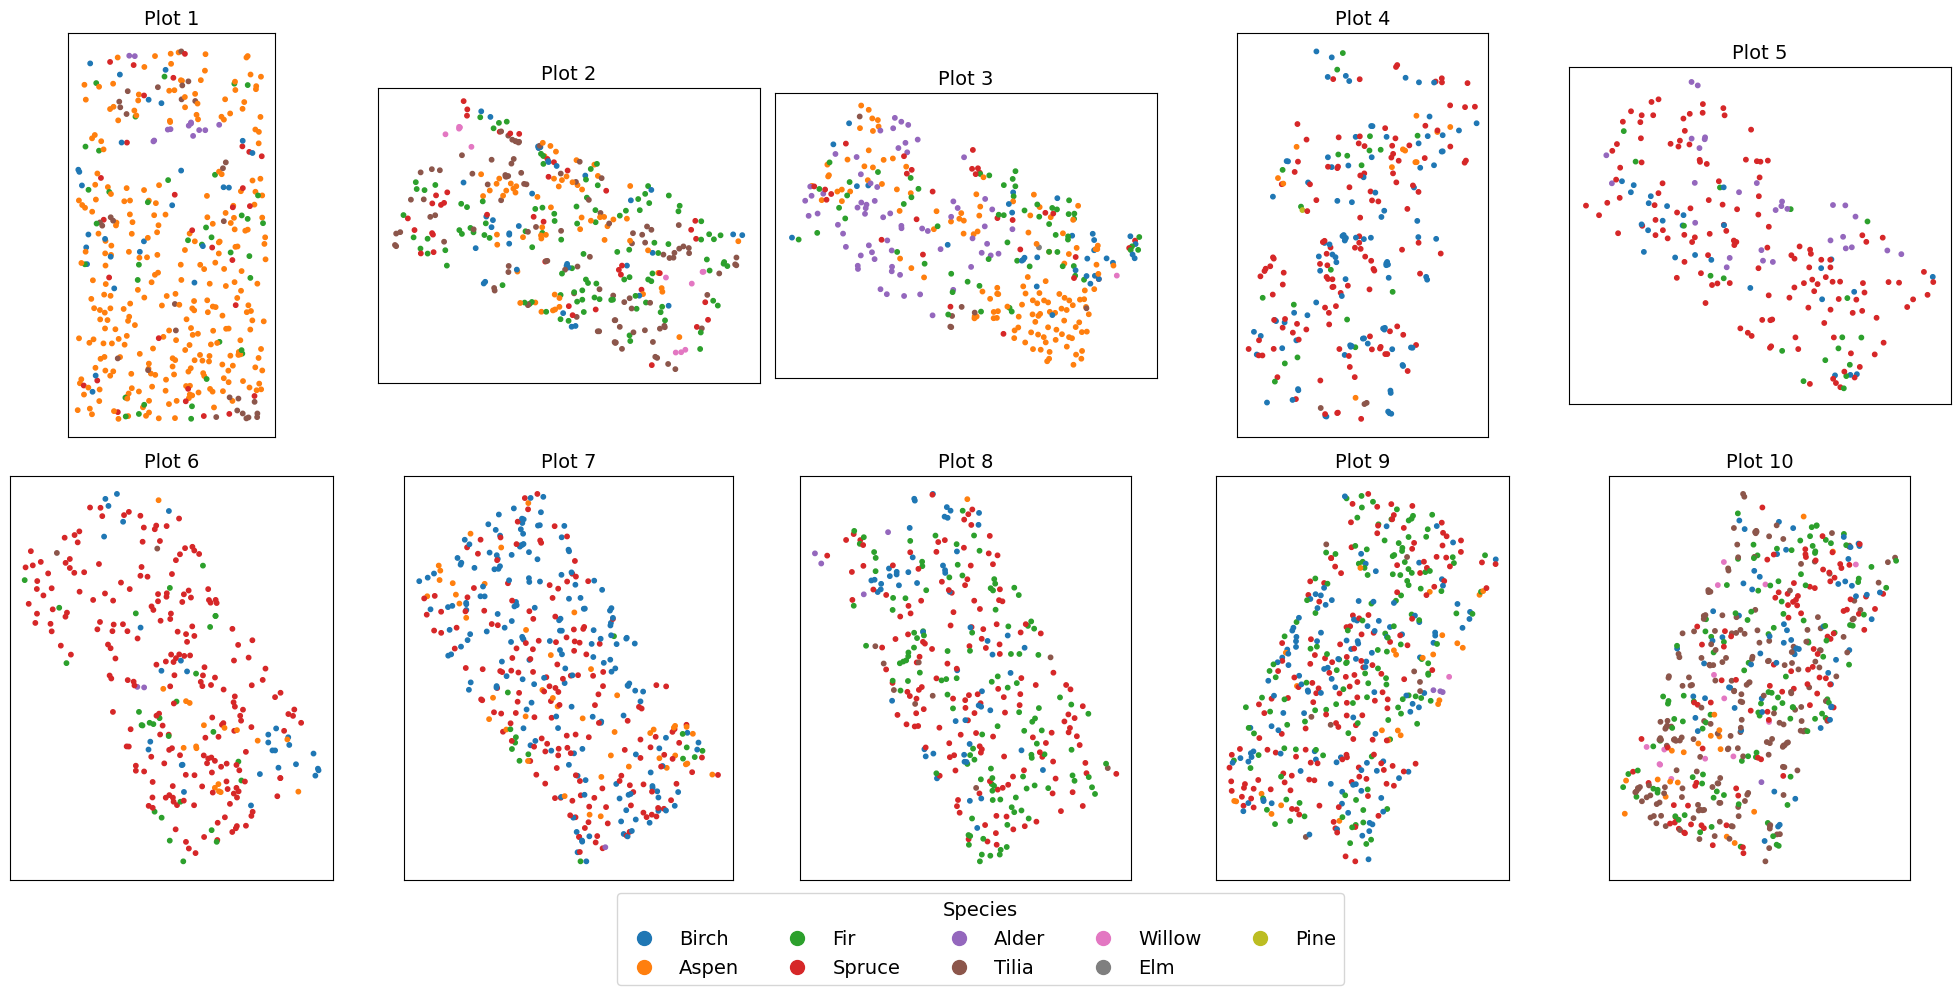

In [14]:
palette = sns.color_palette("tab10", n_colors=len(field_survey['species'].unique()))
species_colors = {species: color for species, color in zip(field_survey['species'].unique(), palette)}

cmap = ListedColormap([species_colors[species] for species in species_colors.keys()])

fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, ax in enumerate(axes.flatten(), start=1): 
    
    subset = field_survey.query(f"plot == {i}").copy()
    subset['species'] = pd.Categorical(subset['species'], categories=species_colors.keys())


    subset.plot(
        ax=ax,
        column="species",
        legend=False, 
        s=10,
        aspect="equal",
        cmap=cmap,  
    )
    ax.set_title(f"Plot {i}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

handles = [
    plt.Line2D([0], [0], marker='o', color=color, markersize=10, linestyle='', label=species)
    for species, color in species_colors.items()
]
fig.legend(
    handles,
    species_colors.keys(),
    loc="lower center",  
    title="Species",
    fontsize=14,
    title_fontsize=14,
    ncol=5,  
)

plt.tight_layout(rect=[0, 0.1, 1, 1])  
plt.show()


# RGB images

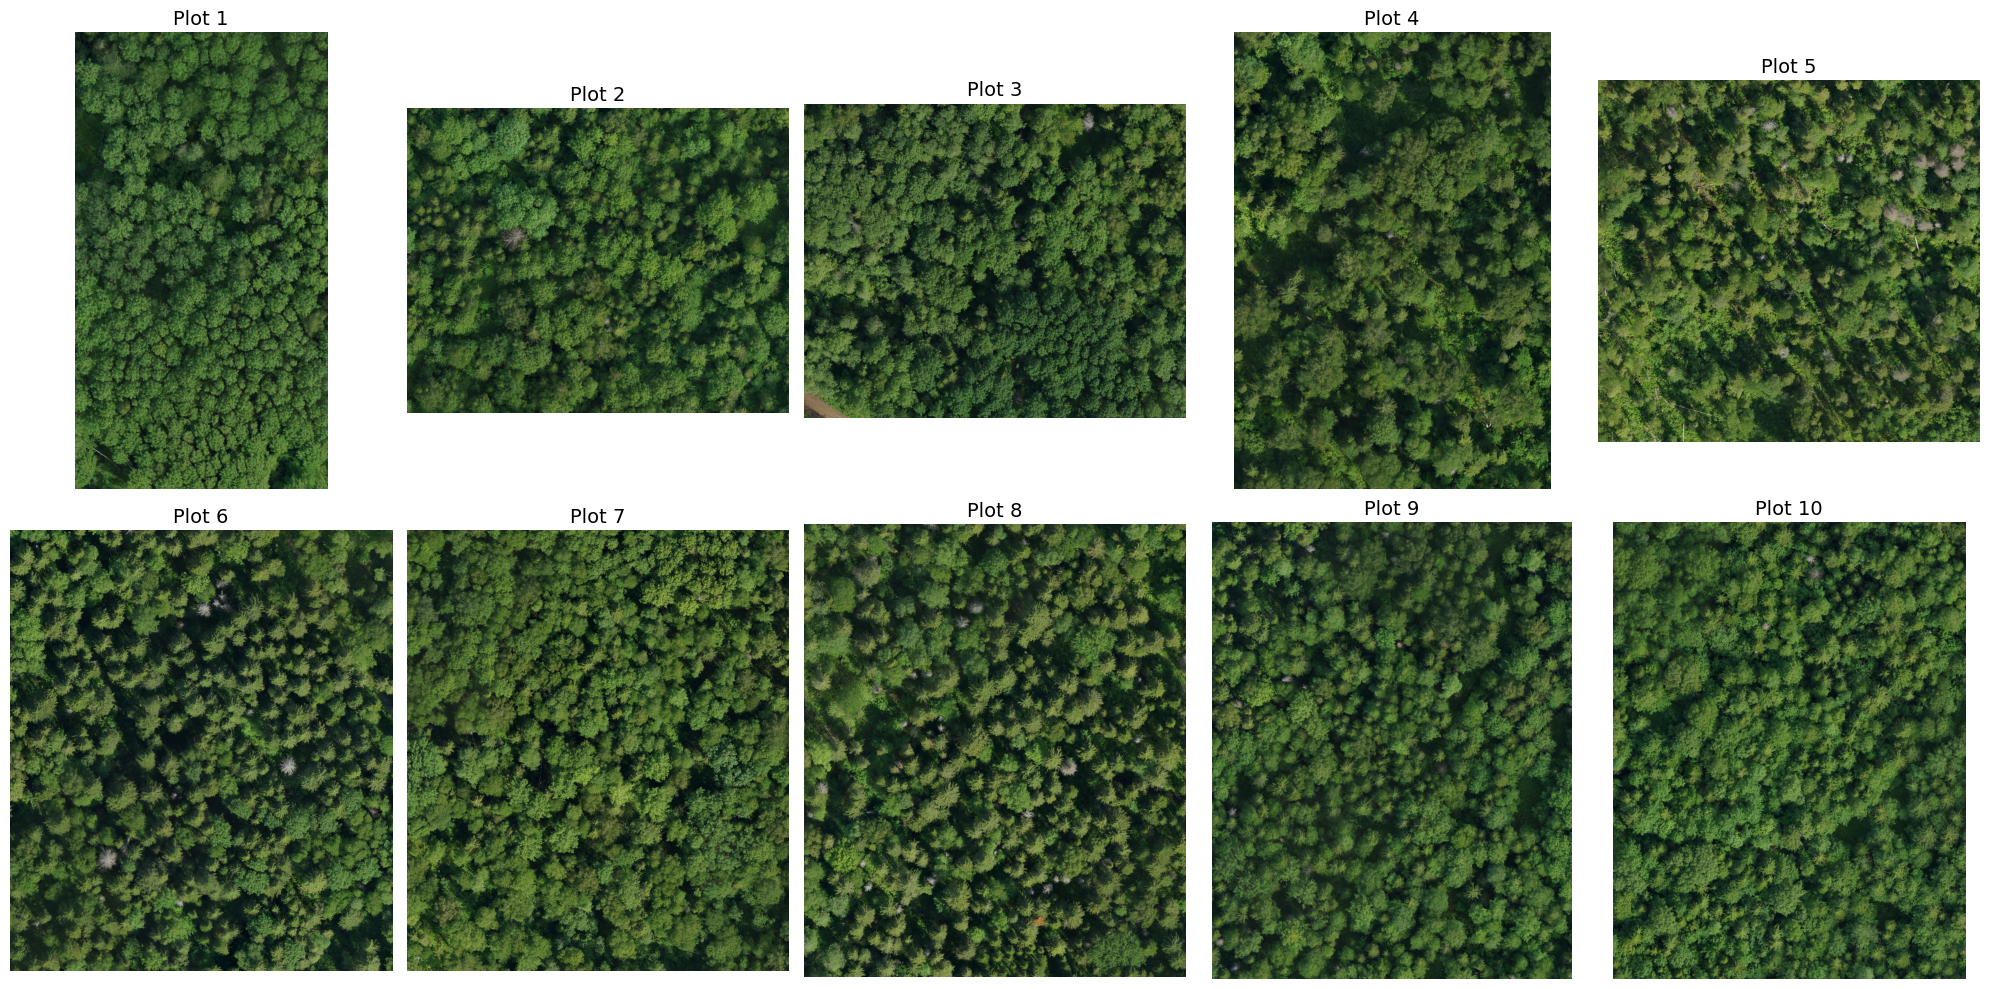

In [15]:
directory = "../data/ortho/"
file_prefix = "plot_"
file_extension = ".tif"

plot_files = [f"{directory}{file_prefix}{i:02d}{file_extension}" for i in range(1, 11)]

fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, (ax, plot_file) in enumerate(zip(axes.flatten(), plot_files)):
    with rasterio.open(plot_file) as f:
        plot_data = f.read()  

    # Plot the image
    ax.imshow(np.rollaxis(plot_data, 0, 3) / 255.0, clim=(0, 255))  
    ax.set_title(f"Plot {i + 1}", fontsize=14) 
    ax.axis('off')  


plt.tight_layout()
plt.show()

# Point clouds

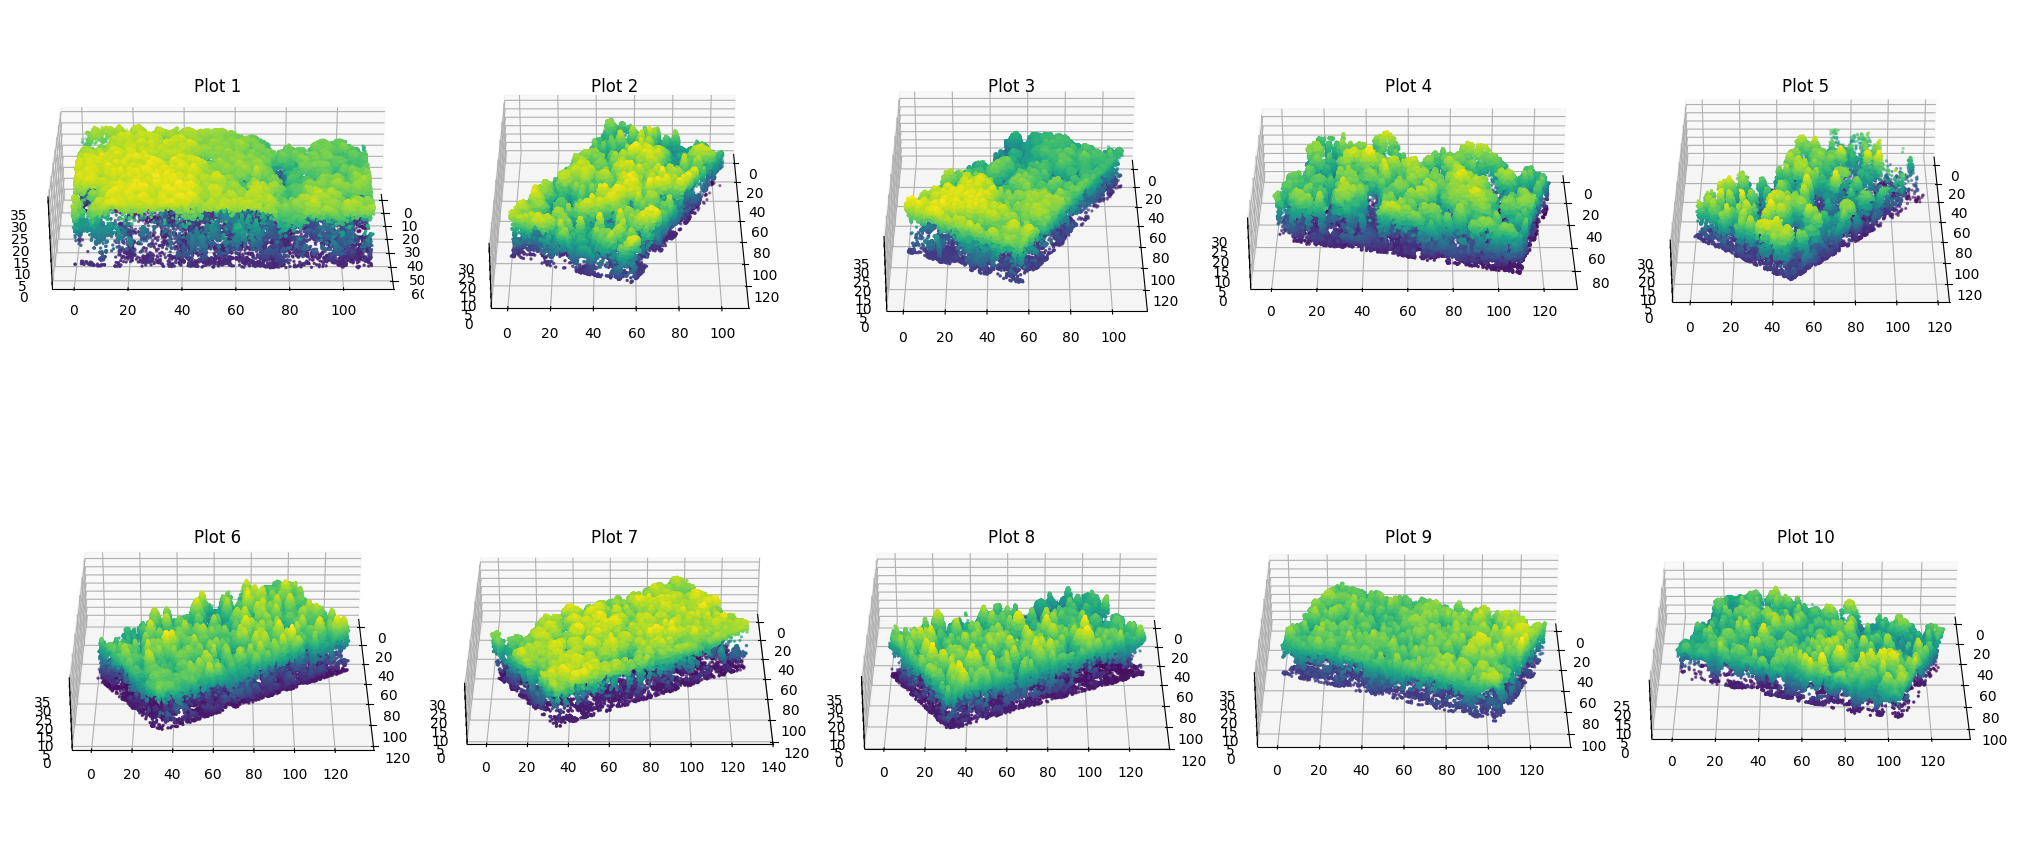

In [16]:
plot_files = [f"../data/als/plot_{i:02d}.las" for i in range(1, 11)]

fig = plt.figure(figsize=(20, 10))

for i, plot_file in enumerate(plot_files, start=1):
    plot = laspy.read(plot_file).xyz
    plot -= plot.min(axis=0, keepdims=True)

    ax = fig.add_subplot(2, 5, i, projection="3d")
    
    ax.scatter(
        *plot.swapaxes(0, 1),
        c=plot[:, 2],  # Color by the z-coordinate (height)
        s=2,
    )

    ax.view_init(elev=30, azim=0)
    ax.set_title(f"Plot {i}", y=0.83)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()


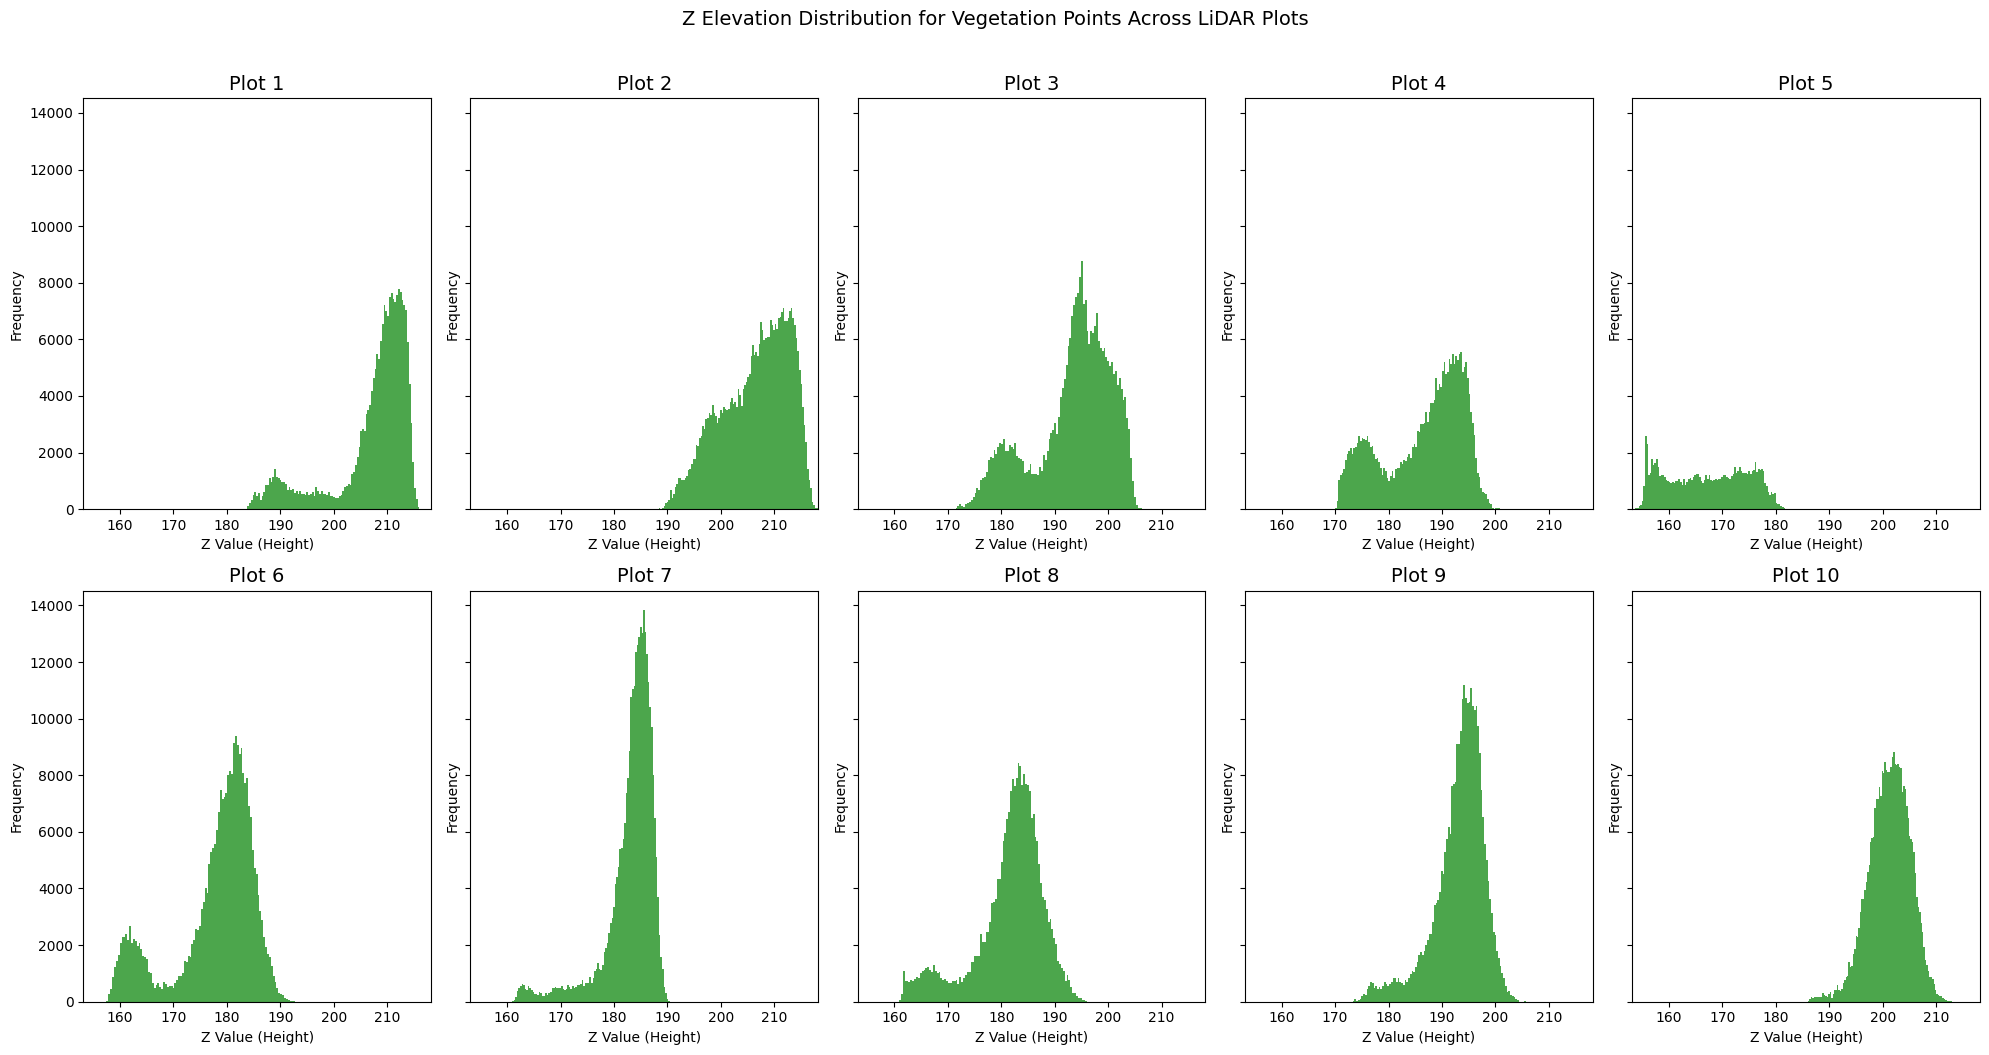

In [28]:
z_min, z_max = float('inf'), float('-inf')

for plot_file in plot_files:
    las = read(plot_file)
    lidar_points = np.array((las.x, las.y, las.z, las.classification)).transpose()
    columns = ['x', 'y', 'z', 'classification']
    lidar_df = pd.DataFrame(lidar_points, columns=columns)
    vegetation_df = lidar_df[lidar_df['classification'] == 5.0]
    
    z_min = min(z_min, vegetation_df['z'].min())
    z_max = max(z_max, vegetation_df['z'].max())

fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharey=True)

for i, plot_file in enumerate(plot_files, start=1):
    las = read(plot_file)
    
    lidar_points = np.array((las.x, las.y, las.z, las.classification)).transpose()
    
    columns = ['x', 'y', 'z', 'classification']
    lidar_df = pd.DataFrame(lidar_points, columns=columns)
    
    vegetation_df = lidar_df[lidar_df['classification'] == 5.0]
    
    ax = axes[(i - 1) // 5, (i - 1) % 5]  
    ax.hist(vegetation_df['z'], bins=100, color='green', alpha=0.7)
    ax.set_title(f"Plot {i}", fontsize=14)
    ax.set_xlabel("Z Value (Height)", fontsize = 10)
    ax.set_ylabel("Frequency", fontsize = 10)
    
    ax.set_xlim(z_min, z_max)
    ax.tick_params(axis='y', labelsize=10)  # Y-tick font size
    ax.tick_params(axis='x', which='both', direction='out', labelsize=10)

plt.tight_layout()
fig.suptitle("Z Elevation Distribution for Vegetation Points Across LiDAR Plots",
             fontsize=14, y=1.05)
plt.show()
